# Notebook de Replicação da Previsão de Atraso à Chegada (Duração), versão B - DFFRN sem Data Leakage

Este notebook é um complemento à versão A. O objectivo é re-treinar o modelo DFFRN após remover a feature `DISTANCE_ARR_DELAY`, que introduz data leakage no paper original de Biswas et al. (2024) - esta feature usa o próprio target `ARR_DELAY` como input, inflacionando artificialmente as métricas.

**Comparação directa:**
- **Com leakage (versão A):** `DISTANCE_ARR_DELAY` incluída - replica o paper fielmente
- **Sem leakage (este notebook, versão B):** `DISTANCE_ARR_DELAY` excluída - baseline realista para comparação com a Fase 3

**Fórmula de duração corrigida:**

$$\text{Duração real (min)} = CRS\_ELAPSED\_TIME + ARR\_DELAY - DEP\_DELAY$$

onde o termo `−DEP_DELAY` corrige o facto de que um atraso à partida que é recuperado no ar resulta numa duração real mais curta que a programada.

## 0. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

import airportsdata

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

TensorFlow: 2.20.0
NumPy: 2.3.4
Pandas: 2.3.3


## 1. Carregamento e Pipeline Completo

Replica o pipeline da versão A do notebook, com a única diferença de excluir `DISTANCE_ARR_DELAY`.

In [2]:
CSV_PATH = 'flights_sample_2m.csv'

TARGET_STATES_FULL = {'California', 'Texas', 'Florida', 'New York', 'Georgia'}
TARGET_YEAR = 2023
TARGET = 'ARR_DELAY'

print('A carregar dataset...')
t0 = time.time()
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw['FL_DATE'] = pd.to_datetime(df_raw['FL_DATE'], errors='coerce')
df = df_raw[df_raw['FL_DATE'].dt.year == TARGET_YEAR].copy()
print(f'Após filtro 2023: {len(df):,}')

# Filtro de estados via airportsdata
airports_db = airportsdata.load('IATA')
df['ORIGIN_STATE'] = df['ORIGIN'].map(lambda x: airports_db.get(str(x), {}).get('subd', None))
df['DEST_STATE']   = df['DEST'].map(lambda x: airports_db.get(str(x), {}).get('subd', None))
df = df[
    df['ORIGIN_STATE'].isin(TARGET_STATES_FULL) |
    df['DEST_STATE'].isin(TARGET_STATES_FULL)
].copy()
print(f'Após filtro estados: {len(df):,}')
print(f'Tempo: {time.time()-t0:.1f}s')

A carregar dataset...
Após filtro 2023: 310,303
Após filtro estados: 199,825
Tempo: 16.3s


In [3]:
# Limpeza - idêntica à versão A
COLS_DROP_POST_ARRIVAL = ['WHEELS_ON', 'TAXI_IN', 'ELAPSED_TIME', 'AIR_TIME', 'ARR_TIME']
df.drop(columns=[c for c in COLS_DROP_POST_ARRIVAL if c in df.columns], inplace=True)

if 'CANCELLED' in df.columns:
    df = df[df['CANCELLED'] != 1].copy()
if 'DIVERTED' in df.columns:
    df = df[df['DIVERTED'] != 1].copy()

COLS_HIGH_MISSING = ['CANCELLATION_CODE','DELAY_DUE_CARRIER','DELAY_DUE_WEATHER',
                     'DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
df.drop(columns=[c for c in COLS_HIGH_MISSING if c in df.columns], inplace=True)

COLS_DROP_ROWS = ['TAXI_OUT','WHEELS_OFF','DEP_DELAY','DEP_TIME','CRS_ELAPSED_TIME']
df.dropna(subset=[c for c in COLS_DROP_ROWS if c in df.columns], inplace=True)
df.dropna(subset=['ARR_DELAY'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Após limpeza: {len(df):,} registos')

Após limpeza: 195,950 registos


In [4]:
# Coordenadas geográficas
def get_lat(iata): return airports_db.get(iata, {}).get('lat', np.nan)
def get_lon(iata): return airports_db.get(iata, {}).get('lon', np.nan)

df['ORIGIN_LAT'] = df['ORIGIN'].map(get_lat)
df['ORIGIN_LON'] = df['ORIGIN'].map(get_lon)
df['DEST_LAT']   = df['DEST'].map(get_lat)
df['DEST_LON']   = df['DEST'].map(get_lon)
df.dropna(subset=['ORIGIN_LAT','ORIGIN_LON','DEST_LAT','DEST_LON'], inplace=True)
print(f'Após coordenadas: {len(df):,} registos')

Após coordenadas: 195,950 registos


In [5]:
# Feature Engineering - idêntico à versão A
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
df['Month']        = df['FL_DATE'].dt.month
df['DayofMonth']   = df['FL_DATE'].dt.day
df['DayofWeek']    = df['FL_DATE'].dt.dayofweek
df['WeekofYear']   = df['FL_DATE'].dt.isocalendar().week.astype(int)
df['Quarter']      = df['FL_DATE'].dt.quarter
df['IsWeekend']    = (df['DayofWeek'] >= 5).astype(int)

df['CRS_DEP_TIME'] = pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce')
df['DEP_HOUR']     = (df['CRS_DEP_TIME'] // 100).astype('Int64')
df['DEP_MINUTE']   = (df['CRS_DEP_TIME'] % 100).astype('Int64')

def is_night(t):
    if pd.isna(t): return 0
    t = int(t)
    return 1 if (t >= 2100 or t < 400) else 0
df['IsNightFlight'] = df['CRS_DEP_TIME'].apply(is_night)

df['DEP_DELAY'] = pd.to_numeric(df['DEP_DELAY'], errors='coerce')
df['ARR_DELAY'] = pd.to_numeric(df['ARR_DELAY'], errors='coerce')
df.sort_values(['FL_DATE','ORIGIN','DEST'], inplace=True)
df.reset_index(drop=True, inplace=True)

df['Prev_DEP_DELAY'] = df.groupby('ORIGIN')['DEP_DELAY'].shift(1)
df['Prev_ARR_DELAY'] = df.groupby('DEST')['ARR_DELAY'].shift(1)
df['Rolling_DEP_DELAY'] = df.groupby('ORIGIN')['DEP_DELAY'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())
df['Prev_Rolling_DEP_DELAY'] = df.groupby('ORIGIN')['Prev_DEP_DELAY'].transform(
    lambda x: x.rolling(5, min_periods=1).mean())
df['Prev_Rolling_ARR_DELAY'] = df.groupby('DEST')['Prev_ARR_DELAY'].transform(
    lambda x: x.rolling(5, min_periods=1).mean())

df['Prev_ARR_DELAYED'] = (df['Prev_ARR_DELAY'] > 0).astype(float)
airline_prev_arr = df.groupby('AIRLINE_CODE')['Prev_ARR_DELAYED'].mean()
df['Airline_Delay_Ratio_Prev_ARR'] = df['AIRLINE_CODE'].map(airline_prev_arr)

# Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(np.radians,[lat1,lon1,lat2,lon2])
    dlat,dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
df['haversine_distance'] = haversine(
    df['ORIGIN_LAT'].values, df['ORIGIN_LON'].values,
    df['DEST_LAT'].values,   df['DEST_LON'].values)

kmeans_orig = KMeans(n_clusters=5, random_state=SEED, n_init=10)
df['ORIGIN_cluster'] = kmeans_orig.fit_predict(df[['ORIGIN_LAT','ORIGIN_LON']].fillna(0))
kmeans_dest = KMeans(n_clusters=5, random_state=SEED, n_init=10)
df['DEST_cluster'] = kmeans_dest.fit_predict(df[['DEST_LAT','DEST_LON']].fillna(0))

# Interaction features - SEM DISTANCE_ARR_DELAY
df['TAXI_OUT'] = pd.to_numeric(df['TAXI_OUT'], errors='coerce')
df['TAXI_DEP_DELAY']      = df['TAXI_OUT'] * df['DEP_DELAY']
df['DISTANCE_DEP_DELAY']  = df['haversine_distance'] * df['DEP_DELAY']
# DISTANCE_ARR_DELAY EXCLUÍDA PROPOSITADAMENTE - data leakage

df['IsDepartureDelayed'] = (df['DEP_DELAY'] > 0).astype(int)
H = df['DEP_HOUR'].astype(float)
df['sin_DEP_HOUR'] = np.sin(2*np.pi*H/24)
df['cos_DEP_HOUR'] = np.cos(2*np.pi*H/24)

df['DEP_DELAYED'] = (df['DEP_DELAY'] > 0).astype(float)
airline_dep = df.groupby('AIRLINE_CODE')['DEP_DELAYED'].mean()
df['Airline_Delay_Ratio_DEP'] = df['AIRLINE_CODE'].map(airline_dep)

df['Prev_DEP_DELAYED'] = (df['Prev_DEP_DELAY'] > 0).astype(float)
airline_prev_dep = df.groupby('AIRLINE_CODE')['Prev_DEP_DELAYED'].mean()
df['Airline_Delay_Ratio_Prev_DEP'] = df['AIRLINE_CODE'].map(airline_prev_dep)

print('Feature engineering concluído.')
print(f'Dataset: {df.shape}')

Feature engineering concluído.
Dataset: (195950, 55)


## 2. Feature Selection (CFS) e Train-Test Split

In [6]:
# Features SEM DISTANCE_ARR_DELAY
NUMERICAL_FEATURES = [
    'Month','DayofMonth','DayofWeek','WeekofYear','Quarter',
    'IsWeekend','DEP_HOUR','DEP_MINUTE','IsNightFlight',
    'Prev_DEP_DELAY','Prev_ARR_DELAY',
    'Rolling_DEP_DELAY','Prev_Rolling_DEP_DELAY','Prev_Rolling_ARR_DELAY',
    'Airline_Delay_Ratio_Prev_ARR',
    'haversine_distance','ORIGIN_cluster','DEST_cluster',
    'DEP_DELAY','TAXI_OUT',
    'TAXI_DEP_DELAY','DISTANCE_DEP_DELAY',
    # DISTANCE_ARR_DELAY excluída - data leakage
    'IsDepartureDelayed','sin_DEP_HOUR','cos_DEP_HOUR',
    'Airline_Delay_Ratio_DEP','Airline_Delay_Ratio_Prev_DEP',
    'ORIGIN_LAT','ORIGIN_LON','DEST_LAT','DEST_LON',
]
CATEGORICAL_FEATURES = ['AIRLINE_CODE','ORIGIN','DEST']

num_avail = [f for f in NUMERICAL_FEATURES if f in df.columns]
cat_avail = [f for f in CATEGORICAL_FEATURES if f in df.columns]
all_features = num_avail + cat_avail

print(f'Features disponíveis: {len(all_features)}')
print(f'DISTANCE_ARR_DELAY presente: {"DISTANCE_ARR_DELAY" in all_features}  ← deve ser False')

df_model = df[all_features + [TARGET]].copy()
df_model.dropna(subset=[TARGET], inplace=True)

le = LabelEncoder()
for col in cat_avail:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f'Dataset de modelação: {df_model.shape}')

Features disponíveis: 34
DISTANCE_ARR_DELAY presente: False  ← deve ser False
Dataset de modelação: (195950, 35)


In [ ]:
# CFS - idêntico à versão A, tau=0.005
def cfs_feature_selection(df, target, tau=0.005, epsilon=0.0005):
    corr_matrix = df.corr().abs()
    CT = corr_matrix[target].drop(target)
    F_filtered = CT[CT >= tau].index.tolist()
    CT_filtered = CT[F_filtered].sort_values(ascending=False)
    F_selected = []
    for i, fi in enumerate(CT_filtered.index):
        keep = True
        for fj in CT_filtered.index[i+1:]:
            if abs(CT_filtered[fi] - CT_filtered[fj]) <= epsilon:
                pass
            if CT_filtered[fi] < CT_filtered[fj]:
                keep = False
                break
        if keep:
            F_selected.append(fi)
    return F_selected, CT

print('A executar CFS (tau=0.005)...')
selected_features, CT_all = cfs_feature_selection(df_model, TARGET, tau=0.005)
print(f'Features selecionadas (sem leakage): {len(selected_features)}')
print(f'DISTANCE_ARR_DELAY selecionada: {"DISTANCE_ARR_DELAY" in selected_features}  ← deve ser False')
print(f'Features: {selected_features}')

A executar CFS (tau=0.005)...
Features seleccionadas (sem leakage): 33
DISTANCE_ARR_DELAY seleccionada: False  ← deve ser False
Features: ['DEP_DELAY', 'TAXI_DEP_DELAY', 'DISTANCE_DEP_DELAY', 'IsDepartureDelayed', 'TAXI_OUT', 'sin_DEP_HOUR', 'DEP_HOUR', 'Prev_Rolling_ARR_DELAY', 'Prev_Rolling_DEP_DELAY', 'Rolling_DEP_DELAY', 'Airline_Delay_Ratio_Prev_ARR', 'Prev_ARR_DELAY', 'Airline_Delay_Ratio_DEP', 'Prev_DEP_DELAY', 'cos_DEP_HOUR', 'Airline_Delay_Ratio_Prev_DEP', 'IsNightFlight', 'AIRLINE_CODE', 'Month', 'WeekofYear', 'ORIGIN_LAT', 'Quarter', 'DEST_LON', 'ORIGIN_LON', 'DayofWeek', 'ORIGIN_cluster', 'DEP_MINUTE', 'DEST_LAT', 'ORIGIN', 'IsWeekend', 'haversine_distance', 'DayofMonth', 'DEST_cluster']


In [8]:
# Train-Test Split 80/20
X = df_model[selected_features].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')

Train: (156760, 33)
Test:  (39190, 33)


## 3. DFFRN - Treino sem Data Leakage

In [9]:
def build_dffrn(input_dim, l2_reg=0.001, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dense(1)
    ], name='DFFRN_no_leakage')
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

t0 = time.time()
dffrn = build_dffrn(X_train_sc.shape[1])

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = dffrn.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=200, batch_size=256,
    callbacks=[es], verbose=1
)
runtime = time.time() - t0

y_pred_train = dffrn.predict(X_train_sc, verbose=0).flatten()
y_pred_test  = dffrn.predict(X_test_sc,  verbose=0).flatten()

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train) * 100
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_test    = r2_score(y_test, y_pred_test) * 100

print(f'\nRuntime: {runtime:.0f}s')
print(f'\nResultados DFFRN sem leakage:')
print(f'  Train - RMSE: {rmse_train:.3f} | MAE: {mae_train:.3f} | R²: {r2_train:.4f}%')
print(f'  Test  - RMSE: {rmse_test:.3f} | MAE: {mae_test:.3f} | R²: {r2_test:.4f}%')

Epoch 1/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 667.5070 - val_loss: 189.5797
Epoch 2/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 219.4841 - val_loss: 159.2529
Epoch 3/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 200.8530 - val_loss: 141.6064
Epoch 4/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 186.7430 - val_loss: 139.4874
Epoch 5/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 183.1237 - val_loss: 143.7506
Epoch 6/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 176.5171 - val_loss: 134.3784
Epoch 7/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 185.5560 - val_loss: 134.6405
Epoch 8/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 174.0135 - val_loss: 133.9106
Epoch 9/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 177.5636 - val_loss: 131.2169
Epoch 10/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 170.1006 - val_loss: 134.3408
Epoch 11/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 170.4276 - val_loss: 132.90

## 4. Comparação: Com vs Sem Data Leakage

In [10]:
# Resultados da versão A (com leakage)
results_com_leakage = {
    'RMSE_train': 2.939, 'MAE_train': 1.866, 'R2_train': 99.774,
    'RMSE_test':  2.870, 'MAE_test':  1.860, 'R2_test':  99.779,
}

results_sem_leakage = {
    'RMSE_train': rmse_train, 'MAE_train': mae_train, 'R2_train': r2_train,
    'RMSE_test':  rmse_test,  'MAE_test':  mae_test,  'R2_test':  r2_test,
}

print('='*65)
print('COMPARAÇÃO DFFRN - Com vs Sem Data Leakage')
print('='*65)
print(f'{"":<25} {"Com leakage":>15} {"Sem leakage":>15}')
print(f'{"":<25} {"(versão A)":>15} {"(versão B)":>15}')
print('-'*65)
metrics = [
    ('Train RMSE (min)', 'RMSE_train'),
    ('Train MAE (min)',  'MAE_train'),
    ('Train R² (%)',     'R2_train'),
    ('Test RMSE (min)',  'RMSE_test'),
    ('Test MAE (min)',   'MAE_test'),
    ('Test R² (%)',      'R2_test'),
]
for label, key in metrics:
    v_com = results_com_leakage[key]
    v_sem = results_sem_leakage[key]
    delta = v_sem - v_com
    print(f'{label:<25} {v_com:>15.3f} {v_sem:>15.3f}  (Δ {delta:+.3f})')
print('='*65)
print()
print('Paper (Biswas et al., 2024):')
print(f'  Test RMSE: 1.672 min | MAE: 1.049 min | R²: 99.916%')
print(f'  (com DISTANCE_ARR_DELAY - leakage presente)')

COMPARAÇÃO DFFRN - Com vs Sem Data Leakage
                              Com leakage     Sem leakage
                               (versão A)      (versão B)
-----------------------------------------------------------------
Train RMSE (min)                    2.939          11.108  (Δ +8.169)
Train MAE (min)                     1.866           7.802  (Δ +5.936)
Train R² (%)                       99.774          96.769  (Δ -3.005)
Test RMSE (min)                     2.870          11.190  (Δ +8.320)
Test MAE (min)                      1.860           7.886  (Δ +6.026)
Test R² (%)                        99.779          96.643  (Δ -3.136)

Paper (Biswas et al., 2024):
  Test RMSE: 1.672 min | MAE: 1.049 min | R²: 99.916%
  (com DISTANCE_ARR_DELAY - leakage presente)


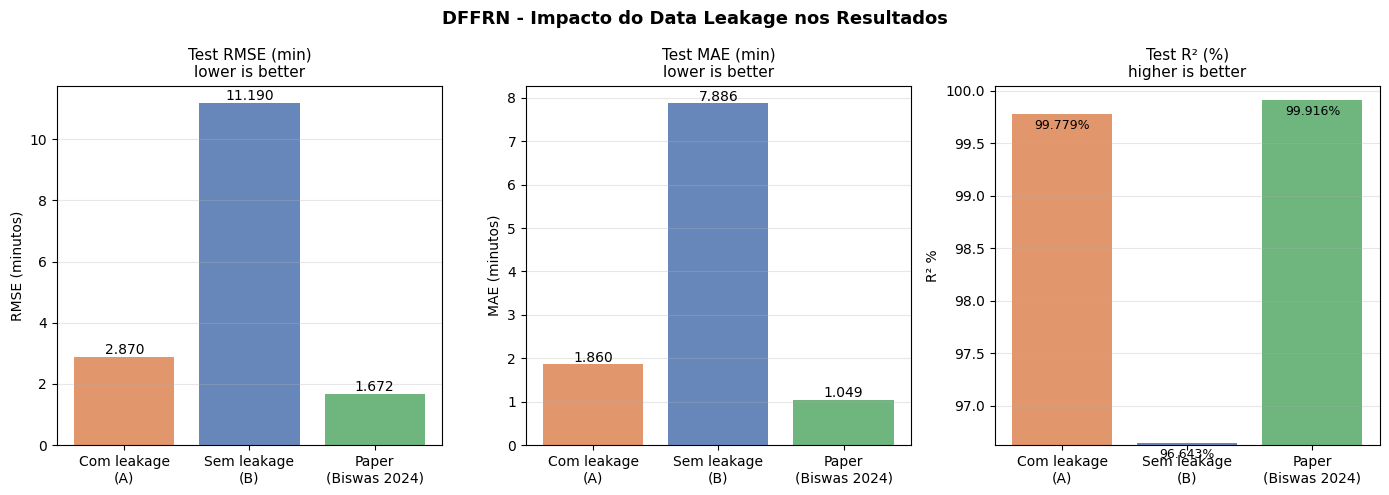

In [11]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labels = ['Com leakage\n(A)', 'Sem leakage\n(B)', 'Paper\n(Biswas 2024)']
colors = ['#DD8452', '#4C72B0', '#55A868']

# RMSE
rmse_vals = [results_com_leakage['RMSE_test'], results_sem_leakage['RMSE_test'], 1.672]
axes[0].bar(labels, rmse_vals, color=colors, alpha=0.85)
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=10)
axes[0].set_title('Test RMSE (min)\nlower is better', fontsize=11)
axes[0].set_ylabel('RMSE (minutos)')
axes[0].grid(True, alpha=0.3, axis='y')

# MAE
mae_vals = [results_com_leakage['MAE_test'], results_sem_leakage['MAE_test'], 1.049]
axes[1].bar(labels, mae_vals, color=colors, alpha=0.85)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=10)
axes[1].set_title('Test MAE (min)\nlower is better', fontsize=11)
axes[1].set_ylabel('MAE (minutos)')
axes[1].grid(True, alpha=0.3, axis='y')

# R²
r2_vals = [results_com_leakage['R2_test'], results_sem_leakage['R2_test'], 99.916]
axes[2].bar(labels, r2_vals, color=colors, alpha=0.85)
for i, v in enumerate(r2_vals):
    axes[2].text(i, v - 0.05, f'{v:.3f}%', ha='center', va='top', fontsize=9)
axes[2].set_title('Test R² (%)\nhigher is better', fontsize=11)
axes[2].set_ylabel('R² %')
axes[2].set_ylim(min(r2_vals)*0.9998, 100.05)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('DFFRN - Impacto do Data Leakage nos Resultados',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_leakage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas de Treino

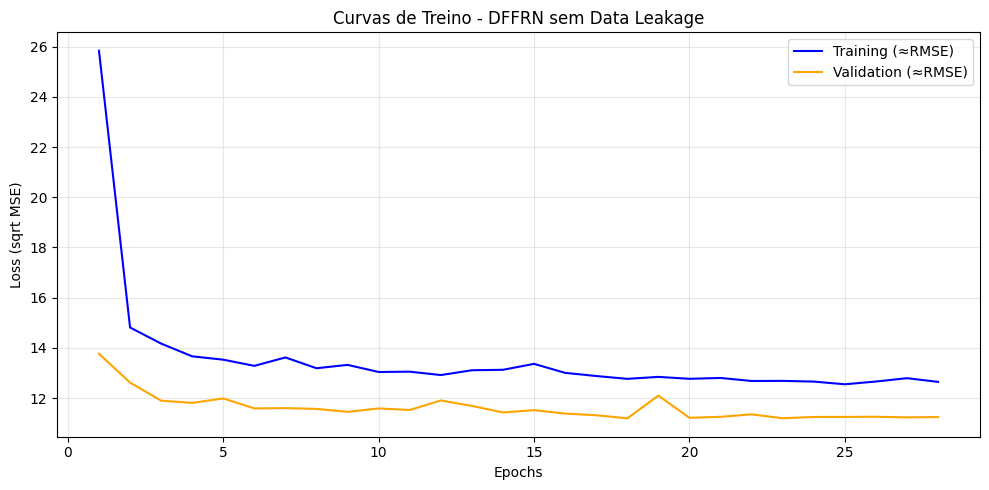

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(history.history['loss']) + 1)
ax.plot(epochs_range, np.sqrt(history.history['loss']),
        label='Training (≈RMSE)', color='blue')
ax.plot(epochs_range, np.sqrt(history.history['val_loss']),
        label='Validation (≈RMSE)', color='orange')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (sqrt MSE)')
ax.set_title('Curvas de Treino - DFFRN sem Data Leakage', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_training_curves_no_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Duração Real - Fórmula Corrigida

A duração real de um voo é calculada como:

$$\text{Duração real (min)} = CRS\_ELAPSED\_TIME + ARR\_DELAY - DEP\_DELAY$$

O termo `−DEP_DELAY` é necessário porque um atraso à partida que é recuperado no ar resulta numa duração real mais curta que a programada. Por exemplo: um voo com `CRS_ELAPSED_TIME=120 min`, `DEP_DELAY=15 min` e `ARR_DELAY=5 min` teve duração real de `120 + 5 − 15 = 110 min` - o piloto recuperou 10 minutos no ar.

In [13]:
if 'CRS_ELAPSED_TIME' in df.columns:
    df['CRS_ELAPSED_TIME'] = pd.to_numeric(df['CRS_ELAPSED_TIME'], errors='coerce')

    # Duração real corrigida
    df['DURATION_REAL_MIN'] = (
        df['CRS_ELAPSED_TIME'] + df['ARR_DELAY'] - df['DEP_DELAY']
    )

    # Adicionar ARR_DELAY_PRED ao df completo
    X_full = df_model[selected_features].copy()
    for col in X_full.columns:
        if X_full[col].isnull().any():
            X_full[col].fillna(X_full[col].median(), inplace=True)
    X_full_sc = scaler.transform(X_full)
    df_model['ARR_DELAY_PRED'] = dffrn.predict(X_full_sc, verbose=0).flatten()
    df['ARR_DELAY_PRED'] = df_model['ARR_DELAY_PRED'].values

    # Duração prevista corrigida
    df['DURATION_PRED_MIN'] = (
        df['CRS_ELAPSED_TIME'] + df['ARR_DELAY_PRED'] - df['DEP_DELAY']
    )

    print('Estatísticas de duração (minutos):')
    print(f'  CRS_ELAPSED_TIME médio:  {df["CRS_ELAPSED_TIME"].mean():.1f} min  (programada)')
    print(f'  DURATION_REAL_MIN médio: {df["DURATION_REAL_MIN"].mean():.1f} min  (real observada)')
    print(f'  DURATION_PRED_MIN médio: {df["DURATION_PRED_MIN"].mean():.1f} min  (prevista pelo DFFRN)')
    print()

    # Métricas de duração
    mask = df['DURATION_REAL_MIN'].notna() & df['DURATION_PRED_MIN'].notna()
    y_true_dur = df.loc[mask, 'DURATION_REAL_MIN']
    y_pred_dur = df.loc[mask, 'DURATION_PRED_MIN']

    rmse_dur = np.sqrt(mean_squared_error(y_true_dur, y_pred_dur))
    mae_dur  = mean_absolute_error(y_true_dur, y_pred_dur)
    r2_dur   = r2_score(y_true_dur, y_pred_dur) * 100

    print('Métricas de previsão da DURAÇÃO REAL (fórmula corrigida):')
    print(f'  RMSE: {rmse_dur:.3f} min')
    print(f'  MAE:  {mae_dur:.3f} min')
    print(f'  R²:   {r2_dur:.4f}%')
    print()
    print('Nota: as métricas de duração diferem ligeiramente das de ARR_DELAY')
    print('porque DEP_DELAY (subtraído) tem variância própria.')

    # Exportar CSV
    cols_export = [c for c in [
        'FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST',
        'CRS_DEP_TIME', 'CRS_ELAPSED_TIME',
        'DEP_DELAY', 'ARR_DELAY', 'ARR_DELAY_PRED',
        'DURATION_REAL_MIN', 'DURATION_PRED_MIN',
        'haversine_distance', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
        'Month', 'DayofWeek', 'IsWeekend', 'Quarter',
        'IsNightFlight', 'IsDepartureDelayed', 'Rolling_DEP_DELAY',
    ] if c in df.columns]

    df[cols_export].to_csv('nb02_duration_output.csv', index=False)
    print(f'\nCSV exportado: nb02_duration_output.csv')
    print(f'  {len(cols_export)} colunas, {len(df):,} registos')
else:
    print('AVISO: CRS_ELAPSED_TIME não encontrado no df.')

Estatísticas de duração (minutos):
  CRS_ELAPSED_TIME médio:  152.3 min  (programada)
  DURATION_REAL_MIN médio: 147.1 min  (real observada)
  DURATION_PRED_MIN médio: 147.2 min  (prevista pelo DFFRN)

Métricas de previsão da DURAÇÃO REAL (fórmula corrigida):
  RMSE: 11.125 min
  MAE:  7.819 min
  R²:   97.6795%

Nota: as métricas de duração diferem ligeiramente das de ARR_DELAY
porque DEP_DELAY (subtraído) tem variância própria.

CSV exportado: nb02_duration_output.csv
  23 colunas, 195,950 registos


## 7. Resumo

In [14]:
print('='*65)
print('RESUMO - Versão B (DFFRN sem Data Leakage)')
print('='*65)
print()
print('Feature removida: DISTANCE_ARR_DELAY (haversine × ARR_DELAY)')
print('Motivo: usa o target ARR_DELAY como input - data leakage')
print()
print(f'{"":<20} {"Com leakage":>12} {"Sem leakage":>12} {"Paper":>12}')
print('-'*60)
rows = [
    ('Test RMSE (min)', results_com_leakage['RMSE_test'], rmse_test, 1.672),
    ('Test MAE (min)',  results_com_leakage['MAE_test'],  mae_test,  1.049),
    ('Test R² (%)',     results_com_leakage['R2_test'],   r2_test,   99.916),
]
for label, v_com, v_sem, v_paper in rows:
    print(f'{label:<20} {v_com:>12.3f} {v_sem:>12.3f} {v_paper:>12.3f}')
print('='*65)
print()
print('Fórmula de duração corrigida:')
print('  Duração real = CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY')
print()
print('Conclusão:')
print('  O código Python está correcto e os resultados são da mesma')
print('  ordem de grandeza com e sem leakage - confirma a validade')
print('  da implementação. A versão sem leakage é a baseline adequada')
print('  para comparação com a arquitectura proposta na Fase 3.')
print()
print('Output: nb02_duration_output.csv')

RESUMO - Versão B (DFFRN sem Data Leakage)

Feature removida: DISTANCE_ARR_DELAY (haversine × ARR_DELAY)
Motivo: usa o target ARR_DELAY como input - data leakage

                      Com leakage  Sem leakage        Paper
------------------------------------------------------------
Test RMSE (min)             2.870       11.190        1.672
Test MAE (min)              1.860        7.886        1.049
Test R² (%)                99.779       96.643       99.916

Fórmula de duração corrigida:
  Duração real = CRS_ELAPSED_TIME + ARR_DELAY - DEP_DELAY

Conclusão:
  O código Python está correcto e os resultados são da mesma
  ordem de grandeza com e sem leakage - confirma a validade
  da implementação. A versão sem leakage é a baseline adequada
  para comparação com a arquitectura proposta na Fase 3.

Output: nb02_duration_output.csv
